In [ ]:
from datasets import load_dataset
# dataset_names = [
#     "weathon/ass_emotion-grpo_flux",
#     "weathon/ass_emotion-dance_flux",
#     "weathon/ass_emotion-flux_dev",
#     "weathon/ass_emotion-flux_krea",
#     "weathon/ass_emotion-nano-banana",
#     "weathon/ass_emotion-stable_diffusion_3.5_large"
# ]
# datasets = [load_dataset(name)["train"] for name in dataset_names]

In [ ]:
# !pip install insightface
# !pip install onnxruntime-gpu

In [ ]:
from datasets import concatenate_datasets
# dataset = concatenate_datasets(datasets)
dataset = load_dataset("weathon/emotion")

README.md:   0%|          | 0.00/584 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/418M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/350M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/396M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/720 [00:00<?, ? examples/s]

In [ ]:
# import torch
# import requests
# from PIL import Image
# from transformers import BlipProcessor, BlipForImageTextRetrieval

# processor = BlipProcessor.from_pretrained("Salesforce/blip-itm-large-coco")
# model = BlipForImageTextRetrieval.from_pretrained("Salesforce/blip-itm-large-coco", torch_dtype=torch.float16).to("cuda")

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'emotion', 'prompt', 'model', 'cropped', 'class_value', 'value', 'itm_scores', 'itm_scores_2'],
        num_rows: 720
    })
})

In [ ]:
# # use BLIP because it should be binary

# def rate(sample):
#   prompt = f"a {sample['emotion']} person in the image"
#   inputs = processor(sample["image"], prompt, return_tensors="pt").to("cuda", torch.float16)
#   print(prompt)
#   itm_scores = model(**inputs)[0]
#   return itm_scores.softmax(-1)[0][1]

In [ ]:
# idx = 4
# print(rate(dataset[idx]))
# print(dataset[idx]["model"])
# dataset[idx]["image"].resize((256, 256))

In [ ]:
# Use a pipeline as a high-level helper
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained("dima806/facial_emotions_image_detection")
model = AutoModelForImageClassification.from_pretrained("dima806/facial_emotions_image_detection").to("cuda")

preprocessor_config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/907 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

In [ ]:
# print(rate(dataset[7]))
# dataset[7]["image"]

In [ ]:
# !pip install mtcnn
# !pip install lz4

In [ ]:
# from mtcnn import MTCNN
# import numpy as np
# from mtcnn.utils.images import load_image

# detector = MTCNN(device="CPU:0")

In [ ]:
# from insightface.app import FaceAnalysis
import cv2
import numpy as np
# app = FaceAnalysis(name="buffalo_l")
# app.prepare(ctx_id=-1)

In [ ]:
from transformers import pipeline

# Use any checkpoint from the hf.co/models?pipeline_tag=zero-shot-object-detection
checkpoint = "iSEE-Laboratory/llmdet_large"
detector = pipeline(model=checkpoint, task="zero-shot-object-detection")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.38G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# from PIL import ImageDraw
# draw = ImageDraw.Draw(image)


# box = prediction_max["box"]
# label = prediction_max["label"]
# score = prediction_max["score"]

# xmin, ymin, xmax, ymax = box.values()
# draw.rectangle((xmin, ymin, xmax, ymax), outline="red", width=1)
# draw.text((xmin, ymin), f"{label}: {round(score,2)}", fill="white")

# image

In [ ]:
# prediction_max

In [ ]:
# [["sad", "disgust", "angry", "fear"], ["happy"]]

In [ ]:
# import torch
# from PIL import Image
# def rate(sample):
#   with torch.no_grad():

#     image = sample["image"]

#     predictions = detector(
#         image,
#         candidate_labels=["human face"],
#         threshold=0.45,
#     )
#     prediction_max = max(predictions, key=lambda x: x["score"])
#     image = np.array(image)
#     box = prediction_max["box"]
#     x1, y1, x2, y2 = box["xmin"], box["ymin"], box["xmax"], box["ymax"]
#     w = x2 - x1
#     h = y2 - y1
#     side = max(w, h)
#     dx = (side - w) // 2
#     dy = (side - h) // 2
#     x1 = max(x1 - dx, 0)
#     y1 = max(y1 - dy, 0)
#     x2 = x1 + side
#     y2 = y1 + side
#     cropped = image[y1:y2, x1:x2]

#     res = model(**processor(Image.fromarray(cropped), return_tensors="pt").to("cuda"))
#     idx = model.config.label2id[sample["emotion"].replace("fearful", "fear")]
#     prob = res.logits.softmax(-1)
#     class_mean = []
#     if sample["emotion"] == "happy":
#       class_mean.append(prob[0][model.config.label2id["happy"]])
#     else:
#       for emotion in ["sad", "disgust", "angry", "fear"]:
#         class_mean.append(prob[0][model.config.label2id[emotion]])
#     class_mean = torch.tensor(class_mean).mean()
#     sample = {}
#     sample["class_value"] = class_mean
#     sample["value"] = prob[0][idx]
#   return sample

In [ ]:
# # dataset = dataset.map(rate)
# import tqdm
# values = []
# for sample in tqdm.tqdm(dataset):
#   values.append(rate(sample))

In [ ]:
# dataset = dataset.remove_columns("value")

In [ ]:
# dataset = dataset.add_column("class_value", [value["class_value"].item() for value in values])
# dataset = dataset.add_column("value", [value["value"].item() for value in values])

In [ ]:
# dataset.push_to_hub("weathon/emotion")

In [ ]:
# import torch
# import requests
# from PIL import Image
# from transformers import BlipProcessor, BlipForImageTextRetrieval

# processor = BlipProcessor.from_pretrained("Salesforce/blip-itm-large-coco")
# model = BlipForImageTextRetrieval.from_pretrained("Salesforce/blip-itm-large-coco", torch_dtype=torch.float16).to("cuda")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.78G [00:00<?, ?B/s]

In [ ]:
import torch
from PIL import Image
import requests
from transformers import AutoProcessor, Blip2ForImageTextRetrieval

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Blip2ForImageTextRetrieval.from_pretrained("Salesforce/blip2-itm-vit-g", dtype=torch.float16)
processor = AutoProcessor.from_pretrained("Salesforce/blip2-itm-vit-g")

In [ ]:
model.to(device)

In [ ]:
image = dataset[3]["cropped"].convert("RGB")
# url = "https://assets.clevelandclinic.org/transform/LargeFeatureImage/cd71f4bd-81d4-45d8-a450-74df78e4477a/Apples-184940975-770x533-1_jpg"
# image = Image.open(requests.get(url, stream=True).raw)
text = f"a photo of a happy huamn face"

with torch.no_grad():
  inputs = processor(images=image, text=text, return_tensors="pt").to(device, torch.float16)
  itm_out = model(**inputs, use_image_text_matching_head=True)


In [ ]:
itm_out["logits_per_image"].softmax(-1)

tensor([[0.5933, 0.4065]], device='cuda:0', dtype=torch.float16)

In [ ]:
probs = torch.nn.functional.softmax(itm_out.logits_per_image, dim=1)
probs

tensor([[0.9941, 0.0060]], device='cuda:0', dtype=torch.float16)

tensor([[ 1.3975, -1.3984]], device='cuda:0', dtype=torch.float16) happy


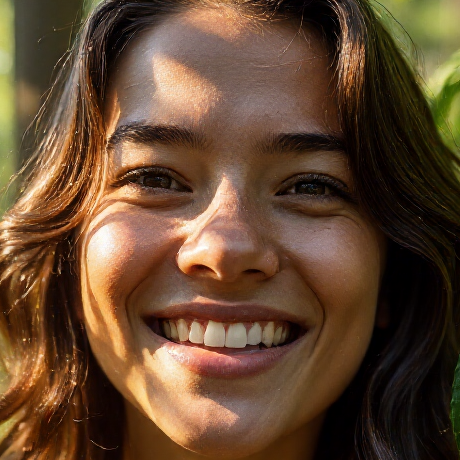

In [ ]:
print(itm_out["logits_per_image"], dataset[3]['emotion'])
dataset[3]["cropped"]

In [ ]:
def rate_blip(samples):
  questions = [f"The face shows {sample} expression" for sample in samples['emotion']]
  images = [sample for sample in samples["cropped"]]
  inputs = processor(images , questions, return_tensors="pt").to("cuda", torch.float16)
  with torch.no_grad():
    itm_scores = model(**inputs, use_image_text_matching_head=True)[0].softmax(-1)
  # samples["itm_scores"] = itm_scores
  return itm_scores

In [ ]:
dataset = dataset["train"]

In [ ]:
batch_size = 128
itm_scores_all = []
for idx in range(0, len(dataset), batch_size):
  print(idx)
  batch = dataset[idx:idx+batch_size]
  batch = rate_blip(batch)
  itm_scores_all.extend(batch)

0
128
256
384
512
640


In [ ]:
dataset = dataset.remove_columns("itm_scores_2")
dataset = dataset.add_column("itm_scores_2", [i[1].item() for i in itm_scores_all])

In [ ]:
# dataset.push_to_hub("weathon/emotion")

In [ ]:
import pandas as pd
df = pd.DataFrame(dataset.remove_columns("image"))

In [ ]:
# df[df["model"] == "dance_flux"].groupby("emotion")["value"].mean()

In [ ]:
# df[df["model"] == "flux_krea"].groupby("emotion")["value"].mean()

In [ ]:
# poor calibration
df["itm_scores_2"] = df["itm_scores_2"]

In [ ]:
df.pivot_table(index="emotion", columns="model", values="itm_scores_2", aggfunc="mean").T

emotion,angry,fearful,happy,sad
model,,,,
dance_flux,0.076749,0.092121,0.056557,0.079318
flux_dev,0.073645,0.062319,0.016162,0.054543
flux_krea,0.275070,0.176340,0.169767,0.192746
grpo_flux,0.098307,0.062330,0.036611,0.060932
nano-banana,0.346502,0.124524,0.051438,0.132715
stable_diffusion_3.5_large,0.404723,0.075455,0.081363,0.095838


0.01384735107421875 happy


array([[[131, 202, 225],
        [126, 193, 219],
        [119, 195, 212],
        ...,
        [  5,  43,  60],
        [  6,  56,  79],
        [ 20,  86, 115]],

       [[123, 192, 221],
        [121, 190, 217],
        [118, 193, 214],
        ...,
        [  9,  46,  66],
        [  9,  51,  74],
        [ 15,  73, 104]],

       [[147, 201, 232],
        [121, 190, 216],
        [105, 187, 208],
        ...,
        [  6,  40,  59],
        [  6,  45,  66],
        [  9,  59,  87]],

       ...,

       [[149, 175,   7],
        [148, 175,   9],
        [148, 175,   6],
        ...,
        [  8,  11,   8],
        [  9,  13,  10],
        [  8,  12,   9]],

       [[149, 175,   8],
        [150, 177,   9],
        [150, 177,   6],
        ...,
        [  8,  12,   9],
        [ 10,  13,  10],
        [  9,  13,  10]],

       [[150, 176,   7],
        [151, 178,   8],
        [151, 178,   7],
        ...,
        [  9,  13,  10],
        [  9,  13,   9],
        [  8,  12,   9]]], dtype=uint8)
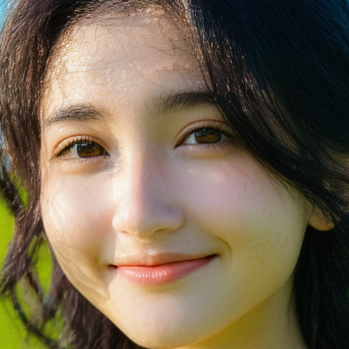

In [ ]:
idx = -1
print(dataset[idx]["itm_scores_2"], dataset[idx]["emotion"])
np.array(dataset[idx]["cropped"] )

In [ ]:
# with torch.no_grad():
#   print(model(**processor(dataset[idx]["cropped"], f"{dataset[idx]['emotion']} expression", return_tensors="pt").to("cuda", torch.float16))[0].softmax(-1))

In [ ]:
df = df.pivot_table(index="emotion", columns="model", values="itm_scores_2", aggfunc="mean").T

In [ ]:
df.to_latex(float_format="{:0.2f}".format)


'\\begin{tabular}{lrrrr}\n\\toprule\nemotion & angry & fearful & happy & sad \\\\\nmodel &  &  &  &  \\\\\n\\midrule\ndance_flux & 0.08 & 0.09 & 0.06 & 0.08 \\\\\nflux_dev & 0.07 & 0.06 & 0.02 & 0.05 \\\\\nflux_krea & 0.28 & 0.18 & 0.17 & 0.19 \\\\\ngrpo_flux & 0.10 & 0.06 & 0.04 & 0.06 \\\\\nnano-banana & 0.35 & 0.12 & 0.05 & 0.13 \\\\\nstable_diffusion_3.5_large & 0.40 & 0.08 & 0.08 & 0.10 \\\\\n\\bottomrule\n\\end{tabular}\n'